# Repeat-seed results

Reads the job logs under `logs/` and builds the summary table. A configuration
submitted with `repeats=N` is averaged over its seeds; a run carried across
several submissions is collapsed back into the one run it was; a run submitted
on its own appears at n=1.

Nothing is keyed on the folder under `logs/` — the config comes from each log's
`Ontology:` line and the model from its `Model:` weights path — so a new folder
is picked up with no change here.

In [108]:
import glob, hashlib, math, os, re, shutil, statistics, subprocess, tempfile
from collections import defaultdict
from pathlib import Path

from IPython.display import SVG, display

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pom.xml").exists())

In [109]:
CONFIGS = [("class_names_exists_thing", "C2"),      # longest first: C1 is a prefix
           ("class_names_exists_partial", "C3"),
           ("class_names", "C1")]

METRICS = ["Macro precision", "Macro recall", "Micro precision", "Micro recall"]

# log label -> column name, scale
COUNTERS = [("counterexamples", "CEs", 1),
            ("Total membership queries", "Mem. queries", 1),
            ("Total time (ms)", "Time (min)", 1 / 60000)]

UNITS = {"second": 1 / 60, "minute": 1, "hour": 60, "day": 1440}

# The order the model blocks appear in, in BOTH tables -- they sit side by side
# in the paper, so they have to agree. Substring match against the name parsed
# out of the weights path, so the short name is enough. Anything unlisted follows,
# alphabetically. Stated here rather than left to encounter order, which put
# whichever model had a repeat sweep first and flipped as soon as one gained or
# lost its seeds.
MODEL_ORDER = ["mistral", "DeepSeek"]


def ordered_models(models):
    def key(model):
        for i, name in enumerate(MODEL_ORDER):
            if name.lower() in model.lower():
                return (i, "")
        return (len(MODEL_ORDER), model)
    return sorted(set(models), key=key)


def model_name(weights):
    # HuggingFace caches under models--org--Name/snapshots/<hash>, so the leaf
    # is a hash and the repo name one level up is the model.
    for part in reversed(weights.strip("/").split("/")):
        if part.startswith("models--"):
            return part.split("--")[-1]
        if part and part != "snapshots" and not re.fullmatch(r"[0-9a-f]{16,}", part):
            return part
    return ""


def parse(path):
    text = open(path, errors="replace").read()
    ont = re.search(r"^Ontology: (.+)$", text, re.M)
    if not ont:
        return None
    tag = (re.search(r"^Run tag: (\S+)", text, re.M) or [None, ""])[1]
    seeds = re.search(r"^Seeds: sampler=(\d+) pac=(\d+)", text, re.M)
    numbered = [int(n) for n in re.findall(r"Counterexample (\d+) at sample", text)]
    elapsed = re.search(r"^Elapsed wallclock time:\s+([\d.]+)\s+(\w+?)s?$", text, re.M)
    row = {
        "config": next((t for k, t in CONFIGS if k in ont.group(1)), "?"),
        "model": model_name((re.search(r"^Model: \S+ \(weights: ([^)]+)\)", text, re.M)
                             or [None, ""])[1]),
        "seed": int(seeds.group(1)) if seeds else -1,
        "pac": int(seeds.group(2)) if seeds else -1,
        # repeats=1 takes a path in submit.sh that sets no run tag, so an
        # explicit seed= counts too. Smoke runs have neither.
        "repeat": bool(re.fullmatch(r"seed\d+", tag))
                  or bool(re.search(r"^Run parameters:.*\bseed=\d+", text, re.M)),
        # Unanchored: vLLM's progress bar ends on a carriage return, so a
        # counterexample announced after one shares its physical line.
        "counterexamples": len(numbered),
        "ce_last": max(numbered, default=0),          # global, continues across a resume
        "resume": bool(re.search(r"^Batching:.*\bresume=true", text, re.M)),
        "wallclock_min": float(elapsed.group(1)) * UNITS.get(elapsed.group(2), 0)
                         if elapsed else None,
        "done": "Ontology learned successfully!" in text,
    }
    for m in METRICS:
        hit = re.search(rf"^{m}: ([\d.]+)$", text, re.M)
        row[m] = float(hit.group(1)) if hit else None
    for label, _, scale in COUNTERS[1:]:
        hit = re.search(rf"^{re.escape(label)}: (\d+)$", text, re.M)
        row[label] = int(hit.group(1)) * scale if hit else None
    return row

In [110]:
# Two-sided 95% t by n; normal value beyond the table.
T95 = {2: 12.706, 3: 4.303, 4: 3.182, 5: 2.776, 6: 2.571, 7: 2.447, 8: 2.365,
       9: 2.306, 10: 2.262, 11: 2.228, 12: 2.201, 15: 2.145, 20: 2.093}

DIGITS = [1, 0, 1, 3, 3, 3, 3]      # counts, then rates


def stats(values):
    n = len(values)
    mean = statistics.mean(values)
    if n < 2:
        return mean, 0.0, 0.0, n
    sd = statistics.stdev(values)
    return mean, T95.get(n, 1.96) * sd / n**0.5, sd, n


def columns(rows):
    out = []
    for label, short, _ in COUNTERS:
        vals = [r[label] for r in rows if r.get(label) is not None]
        out.append((short, stats(vals) if vals else None))
    for m in METRICS:
        vals = [r[m] for r in rows if r[m] is not None]
        out.append((m.replace("precision", "Precision").replace("recall", "Recall"),
                    stats(vals) if vals else None))
    return out


def ci_digits(ci, digits):
    # Widen until one significant figure survives: a CI shown as 0.0 reads as
    # no spread at all.
    return digits if ci <= 0 else max(digits, -math.floor(math.log10(ci)))


def cell(st, digits):
    if st is None:
        return "--"
    mean, ci, _, n = st
    if n < 2:
        return f"{mean:.{digits}f}"
    return rf"{mean:.{digits}f}\,{{\scriptsize $\pm${ci:.{ci_digits(ci, digits)}f}}}"

In [111]:
def load(root):
    """-> (repeat groups by (config, model), single runs by (config, model, seed),
    unfinished repeat paths, unfinished single-run paths).

    Nothing here keys on the log's folder: the config comes from the Ontology
    line and the model from the weights path, so a folder renamed to match a
    template is picked up without the loader being told.
    """
    rows = []
    for path in sorted(glob.glob(os.path.join(root, "logs/**/exactlearner-*.log"),
                                 recursive=True)):
        row = parse(path)
        if row:
            row["path"] = path
            rows.append(row)

    groups, skipped, rest = defaultdict(list), [], defaultdict(list)
    for row in rows:
        if not row["repeat"]:
            rest[(row["config"], row["model"], row["seed"])].append(row)
        elif row["done"]:
            groups[(row["config"], row["model"])].append(row)
        else:
            skipped.append(row["path"])

    # A run submitted without repeats= is a run, whether it took one job or
    # five. It used to be kept only when it had been resumed, so a single job
    # that simply finished -- deepseek-r1-32b on C1 is one -- was collected into
    # oneoff and silently left out of every table. `done` is the only gate now;
    # unfinished singles still drop out, since a run stopped at walltime has no
    # final hypothesis to evaluate.
    runs, unfinished = {}, []
    for key, jobs in rest.items():
        jobs.sort(key=lambda r: r["ce_last"])
        if jobs[-1]["done"]:
            runs[key] = jobs
        else:
            unfinished.extend(j["path"] for j in jobs)
    return groups, runs, skipped, unfinished


def resumed(jobs):
    """Whether this run's figures were carried across a checkpoint."""
    return len(jobs) > 1 or any(j["resume"] for j in jobs)


def run_row(jobs):
    """One run collapsed into a row: a single job, or a resume chain."""
    last = jobs[-1]
    ces = max(j["ce_last"] for j in jobs)          # global counter, not a sum
    earlier = [j["wallclock_min"] for j in jobs[:-1]]
    return {
        "config": last["config"], "model": last["model"], "done": last["done"],
        "counterexamples": ces,
        "resumed": resumed(jobs),
        # Membership queries survive only a run that was never resumed. A job
        # resuming a checkpoint that predates metrics carry-over restarts the
        # counter, so the earlier jobs' share is recorded nowhere -- but a
        # single job's own count is exact, and used to be discarded with it.
        "Total membership queries": None if resumed(jobs)
                                    else last["Total membership queries"],
        # Jobs Slurm stopped are counted at their wallclock, plus the last
        # job's own total.
        "time_min": (sum(earlier) + last["Total time (ms)"])
                    if last["Total time (ms)"] is not None
                    and all(w is not None for w in earlier) else None,
        **{m: last[m] for m in METRICS},
    }

In [112]:
def column_names():
    """The column titles, independent of whether any data was found for them.

    Read off COUNTERS and METRICS rather than off a sample group, so a notebook
    holding only single runs -- no repeat sweep to take headers from -- still
    builds a table instead of raising StopIteration.
    """
    return [short for _, short, _ in COUNTERS] + \
           [m.replace("precision", "Precision").replace("recall", "Recall")
            for m in METRICS]


def table_rows(groups, runs):
    """(model, config, n, cells) -- repeat sweeps first."""
    rows = []
    for (config, model), grp in sorted(groups.items()):
        sts = [st for _, st in columns(grp)]
        rows.append((model, config, str(len(grp)),
                     [cell(st, d) for st, d in zip(sts, DIGITS)]))
    for jobs in sorted(runs.values(), key=lambda j: (j[-1]["model"], j[-1]["config"])):
        run = run_row(jobs)
        if not run["done"]:
            continue
        # Only a resumed run's cost figures are reconstructed. A single job
        # reports its own totals, so marking them $\approx$ would understate
        # what the log actually says.
        mark = (lambda v, d: "--" if v is None else
                (rf"$\approx${v:.{d}f}" if run["resumed"] else f"{v:.{d}f}"))
        cells = [str(run["counterexamples"]),
                 mark(run["Total membership queries"], DIGITS[1]),
                 mark(run["time_min"], DIGITS[2])]
        cells += ["--" if run[m] is None else f"{run[m]:.{DIGITS[len(COUNTERS)]}f}"
                  for m in METRICS]
        rows.append((run["model"], run["config"], "1", cells))
    return rows


def summary_latex(groups, runs):
    rows = table_rows(groups, runs)
    cols = column_names()
    n_cost, lead = len(COUNTERS), 2
    # Two-word titles split over the two header rows; rpartition leaves a
    # one-word title on the lower one.
    heads = [c.rpartition(" ")[::2] for c in cols]

    out = [r"\begin{table*}[]", r"\centering", r"\setlength{\tabcolsep}{4pt}",
           r"\begin{tabular}{@{}lr" + "r" * len(cols) + "@{}}", r"\toprule",
           " & ".join(["", ""] + [rf"\multicolumn{{{n_cost}}}{{c}}{{\textbf{{Learning cost}}}}",
                                  rf"\multicolumn{{{len(cols) - n_cost}}}{{c}}"
                                  rf"{{\textbf{{Learned quality}}}}"]) + r" \\",
           rf"\cmidrule(lr){{{lead + 1}-{lead + n_cost}}} "
           rf"\cmidrule(lr){{{lead + n_cost + 1}-{lead + len(cols)}}}",
           " & ".join(["", ""] + [rf"\textbf{{{t}}}" if t else "" for t, _ in heads]) + r" \\",
           " & ".join([r"\textbf{Config}", r"\textbf{n}"]
                      + [rf"\textbf{{{b}}}" for _, b in heads]) + r" \\",
           r"\midrule"]

    configs = sorted({r[1] for r in rows})
    for i, model in enumerate(ordered_models(r[0] for r in rows)):
        if i:
            out.append(r"\addlinespace")
        out.append(rf"\multicolumn{{{lead + len(cols)}}}{{@{{}}l}}{{\itshape {model}}} \\")
        done = {r[1]: r for r in rows if r[0] == model}
        for config in configs:
            r = done.get(config)
            out.append(" & ".join([config, r[2]] + r[3] if r
                                  else [config] + ["--"] * (1 + len(cols))) + r" \\")

    out += [r"\bottomrule", r"\end{tabular}",
            r"\caption{Mean and 95\% confidence interval over the repeat seeds, "
            r"by model. Equivalence queries are omitted: the learner issues one "
            r"per counterexample and a final one that returns none, so the count "
            r"is always CEs $+$ 1. Rows at $n=1$ are a single run, so they carry no "
            r"interval. Dashes are figures the logs do not give; $\approx$ is "
            r"reconstructed across a resume.}",
            r"\label{table:repeats}", r"\end{table*}"]
    return "\n".join(out)

In [113]:
PREAMBLE = r"""\documentclass[border=6pt,varwidth=40cm]{standalone}
\usepackage{booktabs,caption}
\newsavebox{\tablebox}
\begin{document}
"""

DISPLAY_SCALE = 1.5      # one factor for every table, so type matches across them

UNWRAP = [(r"\\(?:begin|end)\{table\*?\}(?:\[[^\]]*\])?", ""),
          (r"\\centering\b", ""), (r"\\label\{[^}]*\}", "")]


def document(src):
    body = src
    for pattern, repl in UNWRAP:
        body = re.sub(pattern, repl, body)
    caption = re.search(r"\\caption\{([^{}]*)\}", body)
    body = re.sub(r"\\caption\{[^{}]*\}", "", body).strip()
    if caption:
        # Measure the table, then set the caption that wide: otherwise a caption
        # longer than the table sets the width of the whole picture.
        body = (r"\sbox{\tablebox}{" + body + "}\n"
                r"\begin{minipage}{\wd\tablebox}" + "\n" + r"\usebox{\tablebox}" + "\n"
                r"\captionof{table}{" + caption.group(1) + "}\n" + r"\end{minipage}")
    return PREAMBLE + body + "\n" + r"\end{document}" + "\n"


def render(src):
    """SVG for the table, or None if there is no TeX toolchain."""
    if not (shutil.which("latex") and shutil.which("dvisvgm")):
        return None
    with tempfile.TemporaryDirectory() as tmp:
        (Path(tmp) / "t.tex").write_text(document(src))
        run = lambda cmd, **kw: subprocess.run(cmd, cwd=tmp, capture_output=True,
                                               text=True, **kw)
        if run(["latex", "-interaction=nonstopmode", "-halt-on-error", "t.tex"]).returncode:
            return None
        # --no-fonts draws glyphs as paths: dvisvgm's default is SVG Fonts,
        # which no current browser renders.
        if run(["dvisvgm", "--exact-bbox", "--bbox=4pt", "--no-fonts",
                "t.dvi", "-o", "t.svg"]).returncode:
            return None
        svg = (Path(tmp) / "t.svg").read_text()

    # Every SVG on the page shares one id namespace, and dvisvgm numbers glyphs
    # per file, so without a prefix one table draws another's letters.
    tag = "s" + hashlib.md5(svg.encode()).hexdigest()[:8] + "-"
    svg = re.sub(r'(\bid=)(["\'])([^"\']+)\2',
                 lambda m: f"{m[1]}{m[2]}{tag}{m[3]}{m[2]}", svg)
    svg = re.sub(r'((?:xlink:)?href=)(["\'])#([^"\']+)\2',
                 lambda m: f"{m[1]}{m[2]}#{tag}{m[3]}{m[2]}", svg)
    # Opaque white: a transparent page is black-on-black in a dark theme.
    svg = re.sub(r"(<svg\b[^>]*>)",
                 r"\1<rect x='-100%' y='-100%' width='300%' height='300%' fill='#fff'/>",
                 svg, count=1)
    # Scale the picture, not the type: vector, so this is free.
    head = re.match(r"[\s\S]*?<svg\b[^>]*?>", svg)
    size = re.compile(r'\b(width|height)=(["\'])([\d.]+)pt\2')
    found = size.search(head[0])
    if found:
        svg = size.sub(lambda m: f"{m[1]}={m[2]}{float(m[3]) * DISPLAY_SCALE:.4f}pt{m[2]}",
                       head[0]) + svg[head.end():]
    return svg


def show(src):
    svg = render(src)
    display(SVG(svg)) if svg else print(src)

## Results

In [114]:
groups, runs, skipped, unfinished = load(str(root))

print(f"{sum(len(v) for v in groups.values())} repeat runs, {len(runs)} single runs, "
      f"{len(skipped)} unfinished repeats, {len(unfinished)} unfinished single")

# submit.sh pairs the two seeds only inside its repeats loop, so a rerun
# submitted by hand can land with pac=0 and is not the same point in the sweep.
for (config, _), rows in sorted(groups.items()):
    for r in rows:
        if r["seed"] != r["pac"]:
            print(f"  unpaired: {config} sampler={r['seed']} pac={r['pac']}")
for (config, model, _), jobs in sorted(runs.items()):
    print(f"  run: {config} {model} over {len(jobs)} job(s)"
          f"{' (resumed)' if resumed(jobs) else ''}, "
          f"{max(j['ce_last'] for j in jobs)} counterexamples")
for path in unfinished:
    print(f"  unfinished, left out: {path}")


30 repeat runs, 2 single runs, 0 unfinished repeats, 0 unfinished single
  unpaired: C3 sampler=4 pac=0
  unpaired: C3 sampler=7 pac=0
  run: C1 DeepSeek-R1-Distill-Qwen-32B over 1 job(s), 20 counterexamples
  run: C2 DeepSeek-R1-Distill-Qwen-32B over 3 job(s) (resumed), 360 counterexamples


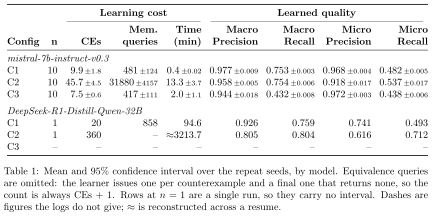

In [115]:
summary_tex = summary_latex(groups, runs)
show(summary_tex)

## Counterexample arrival rate

Whether counterexamples arrive more slowly later in a run. The gap is the samples
drawn since the previous one; each seed is one replicate, so the trend test is a
per-seed rank correlation with the counterexample index and a sign test over the
seeds. A run submitted on its own is one replicate, at n=1. Resumed chains are
left out: the sample counter does not survive a resume intact, so their gaps are
not comparable.

In [116]:
CE_LINE = re.compile(r"Counterexample \d+ at sample (\d+) \(\+(\d+) since the last one\)")
BUDGET = re.compile(r"PAC sample budget \(numberOfSamples\) = (\d+)")

QUARTERS = 4


def arrivals(path):
    """-> (gaps between counterexamples, sample of the last one, budget)."""
    text = open(path, errors="replace").read()
    ces = [(int(s), int(g)) for s, g in CE_LINE.findall(text)]
    budget = BUDGET.search(text)
    return ([g for _, g in ces], ces[-1][0] if ces else 0,
            int(budget[1]) if budget else None)





In [117]:
def arrival_row(rows):
    """Quartile gap means pooled over seeds, plus the per-seed trend."""
    runs = [arrivals(r["path"]) for r in rows]
    runs = [(g, last, budget) for g, last, budget in runs if len(g) >= QUARTERS]
    if not runs:
        return None

    quarters = []
    for q in range(QUARTERS):
        pooled = [g[len(g) * q // QUARTERS:len(g) * (q + 1) // QUARTERS] for g, _, _ in runs]
        quarters.append(statistics.mean([x for chunk in pooled for x in chunk]))

    # Budget left unspent after the last counterexample: high means the run ran
    # out of things to learn long before it ran out of budget.
    tail = statistics.median([(b - last) / b for _, last, b in runs if b])
    return dict(n=len(runs), ces=statistics.median([len(g) for g, _, _ in runs]),
                quarters=quarters, ratio=quarters[-1] / quarters[0], tail=tail)


def arrival_groups(groups, runs):
    """Repeat sweeps, plus every single run that was never resumed.

    A resumed chain stays out for the reason in the note above -- the sample
    counter does not survive a resume, so its gaps are not comparable. A single
    job's are, and leaving them out kept a whole model out of this table when it
    had no repeat sweep.
    """
    merged = {k: list(v) for k, v in groups.items()}
    for jobs in runs.values():
        if resumed(jobs) or not jobs[-1]["done"]:
            continue
        merged.setdefault((jobs[-1]["config"], jobs[-1]["model"]), []).extend(jobs)
    return merged


def arrival_latex(groups):
    heads = [f"Q{q + 1}" for q in range(QUARTERS)] + \
            [r"Q4/Q1", "tail"]
    out = [r"\begin{table*}[]", r"\centering", r"\setlength{\tabcolsep}{4pt}",
           r"\begin{tabular}{@{}lrr" + "r" * len(heads) + "@{}}", r"\toprule",
           " & ".join(["", "", ""] + [rf"\multicolumn{{{QUARTERS}}}{{c}}"
                                      rf"{{\textbf{{Mean gap}}}}",
                                      rf"\multicolumn{{{len(heads) - QUARTERS}}}{{c}}"
                                      rf"{{\textbf{{Trend}}}}"]) + r" \\",
           rf"\cmidrule(lr){{4-{3 + QUARTERS}}} \cmidrule(lr){{{4 + QUARTERS}-{3 + len(heads)}}}",
           " & ".join([r"\textbf{Config}", r"\textbf{n}", r"\textbf{CEs}"]
                      + [rf"\textbf{{{h}}}" for h in heads]) + r" \\",
           r"\midrule"]

    configs = sorted({c for c, _ in groups})
    for i, model in enumerate(ordered_models(m for _, m in groups)):
        if i:
            out.append(r"\addlinespace")
        out.append(rf"\multicolumn{{{3 + len(heads)}}}{{@{{}}l}}{{\itshape {model}}} \\")
        for config in configs:
            st = arrival_row(groups.get((config, model), []))
            if not st:
                out.append(" & ".join([config] + ["--"] * (2 + len(heads))) + r" \\")
                continue
            out.append(" & ".join(
                [config, str(st["n"]), f"{st['ces']:.0f}"]
                + [f"{q:.0f}" for q in st["quarters"]]
                + [f"{st['ratio']:.2f}",
                   f"{st['tail'] * 100:.0f}\\%"]) + r" \\")

    out += [r"\bottomrule", r"\end{tabular}",
            r"\caption{Mean samples between counterexamples, by quarter of each "
            r"run, pooled over the replicates. Tail is the unspent budget. "
            r"A gap cannot exceed the budget left, biasing late quarters down.}",
           r"\label{table:arrivals}", r"\end{table*}"]
    return "\n".join(out)


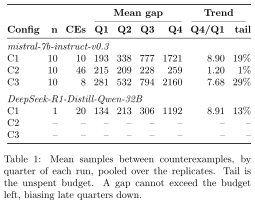

In [118]:
arrival_tex = arrival_latex(arrival_groups(groups, runs))
show(arrival_tex)